# 機械学習・データ分析(レポート作成)

本レポートの目的は、以下の２点を行うことである。  
・A: 釣れる魚の数に天気や気温が与える影響を知る  
・B: 将来的に予測システムを作る前段階として、釣りがうまい人が晴れ・25度のときに何匹釣れるか予想する

## 1.データの概要

今回使用するデータは、天気、気温、そしてユーザー10人がそれぞれ10回ずつ釣った魚の数に関する100件の観測データである。

データの詳細：  
・fish_count：釣れた魚の数を示し、整数値で記録されている  
・weather：天気を示し、「cloudy（曇り）」または「sunny（晴れ）」の2種類  
・temperature：気温を示し、小数点以下1桁までの連続値で記録されている  
・user：釣りをしているユーザーを示し、AからJまでの10人が存在する  

df.info()の実行結果から、全ての行・列で欠損値がないことが確認できた。

### 1.1 ライブラリのインポート・データの読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_url = "https://gist.githubusercontent.com/manemone/fbdca512237b5be8a1dffe6659ad3f5c/raw/fish_count.csv"

df = pd.read_csv(csv_url)

df.head()

,fish_count,weather,temperature,user
0,7,cloudy,20.6,B
1,1,cloudy,6.0,A
2,12,cloudy,27.5,C
3,0,cloudy,8.5,D
4,4,cloudy,15.8,G


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fish_count   100 non-null    int64  
 1   weather      100 non-null    object 
 2   temperature  100 non-null    float64
 3   user         100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ KB


In [4]:
df.nunique() #列ごとのユニークな要素の数

fish_count     12
weather         2
temperature    87
user           10
dtype: int64

In [5]:
user_counts = df.groupby('user').size().reset_index(name='count') #各ユーザーのデータ数を計算する
user_counts

,user,count
0,A,10
1,B,10
2,C,10
3,D,10
4,E,10
5,F,10
6,G,10
7,H,10
8,I,10
9,J,10


In [6]:
df.describe() #基本統計量

,fish_count,temperature
count,100.000000,100.000000
mean,2.480000,15.552000
std,2.999933,9.088193
min,0.000000,0.400000
25%,0.000000,7.550000
50%,1.500000,14.650000
75%,4.000000,24.550000
max,15.000000,29.700000


## 2.探索的データ分析（EDA）

### 2.1 釣れた魚の数（釣果）の分布

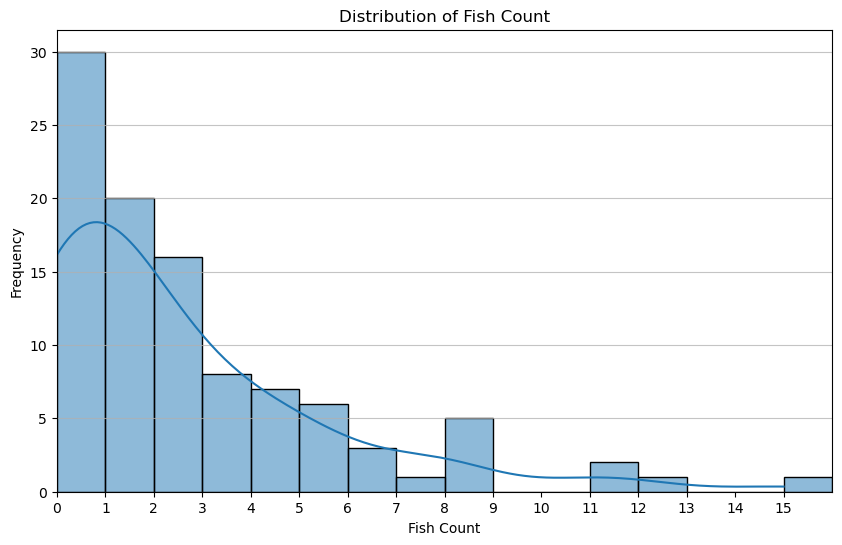

In [7]:
#釣果の分布をヒストグラムで可視化
plt.figure(figsize=(10, 6))
sns.histplot(df['fish_count'], bins=range(int(df['fish_count'].max()) + 2), kde=True)
plt.title('Distribution of Fish Count')
plt.xlabel('Fish Count')
plt.ylabel('Frequency')
plt.xticks(np.arange(0,16,1))
plt.xlim(0,16)
plt.grid(axis='y', alpha=0.75)
plt.show()

釣果の分布を示すヒストグラムは、0匹のケースが最も多く、釣果が高くなるにつれて頻度が減少する、右に歪んだ分布を示した。

### 2.2 釣果と気温の関係

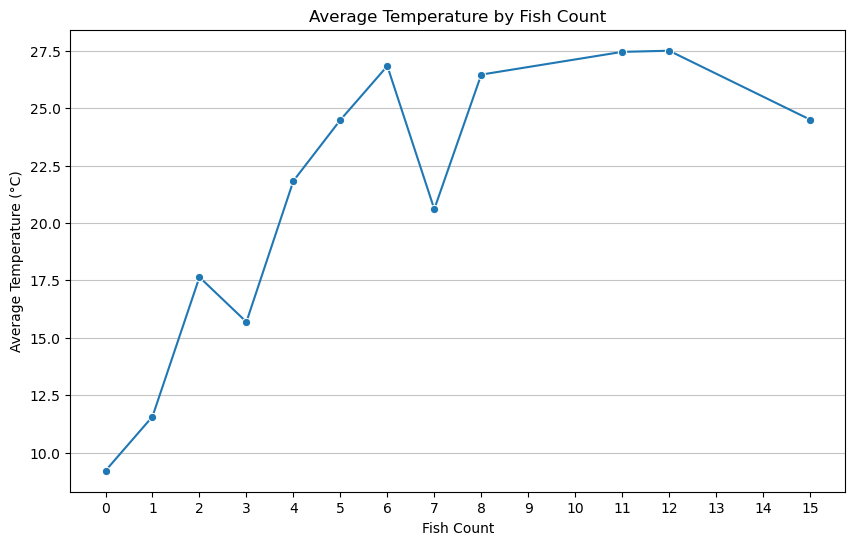

In [8]:
#釣果ごとの平均気温を計算
average_temperature_by_fish_count = df.groupby('fish_count')['temperature'].mean().reset_index()

#釣果と平均気温の関係を折れ線グラフで可視化
plt.figure(figsize=(10, 6))
sns.lineplot(x='fish_count', y='temperature', data=average_temperature_by_fish_count, marker='o')
plt.title('Average Temperature by Fish Count')
plt.xlabel('Fish Count')
plt.ylabel('Average Temperature (°C)')
plt.xticks(np.arange(0, 16, 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

釣果が大きくなるほど平均気温が高くなるという傾向が読み取れる。特に、釣果が0から6匹のとき、この傾向は顕著であり、低い気温では魚が釣れない、またはごく少数しか釣れない状況が多く発生していると推測できる。釣果が7匹のときでは平均気温が大きく降下しているが、これは、2.1の釣果の分布図から、データポイントが少なく変動が大きくなっているためだと考えられる。

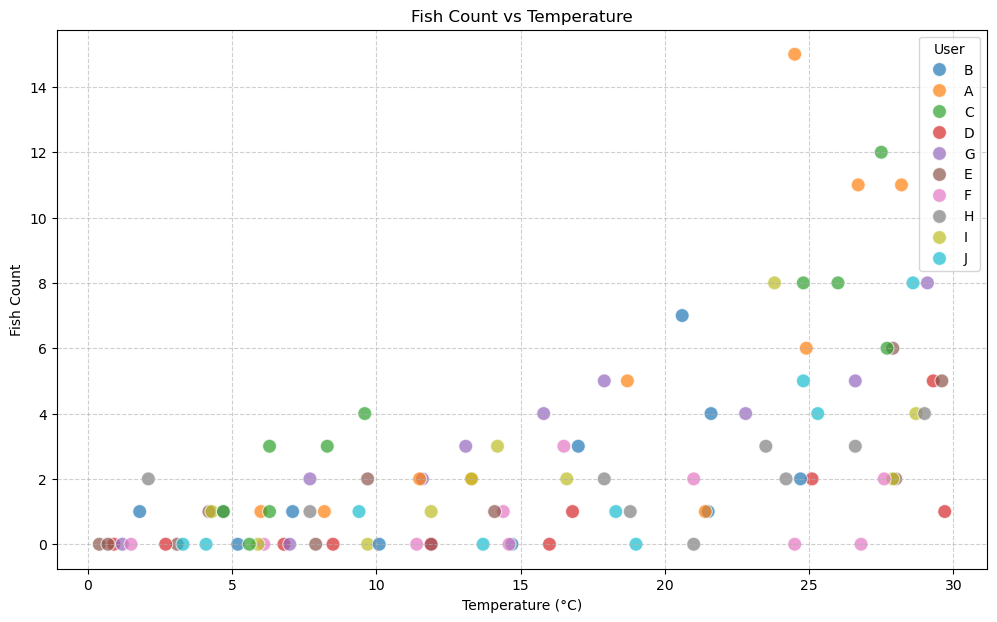

In [30]:
#気温と釣果の関係を散布図で可視化
plt.figure(figsize=(12, 7))
sns.scatterplot(x='temperature', y='fish_count', hue='user', data=df, s=100, alpha=0.7)
plt.title('Fish Count vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fish Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='User')
plt.show()

釣果の大きいデータポイントは特定の気温範囲に集中している傾向が見られた。特に、20℃以上の温かい気温ではより高い釣果がみられる。また、気温が高くなるほど釣果の分散が大きくなっていることが読み取れる。

### 2.3 天気と釣果の関係

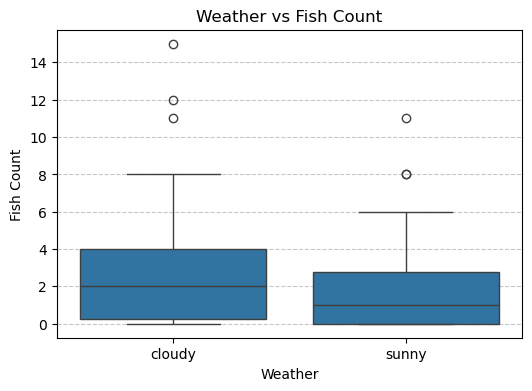

In [10]:
#各天気の釣果を箱ひげ図で可視化
plt.figure(figsize=(6, 4))
sns.boxplot(x='weather', y='fish_count', data=df)
plt.title('Weather vs Fish Count')
plt.xlabel('Weather')
plt.ylabel('Fish Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

天気が曇りの日は晴れの日よりも釣果の中央値が高く、釣果のばらつきも大きい傾向にある。

In [11]:
df.groupby('weather')['fish_count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
cloudy,50.0,2.92,3.379651,0.0,0.25,2.0,4.00,15.0
sunny,50.0,2.04,2.523037,0.0,0.00,1.0,2.75,11.0


具体的な数値を調べるために、晴れの日と曇りの日のデータ数、釣果の平均値、標準偏差、最小値、25%点、中央値、75%点、最大値の表を示した。曇りの日の平均釣果は2.92匹、晴れの日の平均釣果は2.04匹であり、曇りの日の方が晴れの日よりも平均して多くの魚が釣れているという傾向が読み取れる。

### 2.4 ユーザーと釣果の関係

C:\Users\tmkta\AppData\Local\Temp\ipykernel_3668\3969623428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='user', y='fish_count', data=user_avg_fish, palette='viridis')


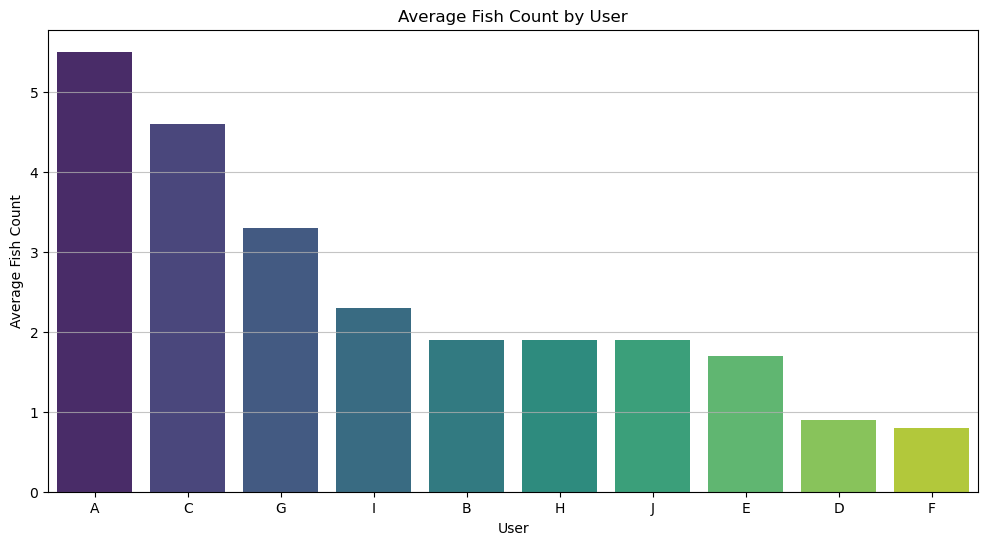

,user,fish_count
0,A,5.5
1,C,4.6
2,G,3.3
3,I,2.3
4,B,1.9
5,H,1.9
6,J,1.9
7,E,1.7
8,D,0.9
9,F,0.8


In [12]:
#各ユーザーの釣果の平均を計算し、降順でソート
user_avg_fish = df.groupby('user')['fish_count'].mean().sort_values(ascending=False).reset_index()

#各ユーザーの釣果の平均を棒グラフで可視化
plt.figure(figsize=(12, 6))
sns.barplot(x='user', y='fish_count', data=user_avg_fish, palette='viridis')
plt.title('Average Fish Count by User')
plt.xlabel('User')
plt.ylabel('Average Fish Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

user_avg_fish

棒グラフから、ユーザー間で釣果に顕著な差があることが読み取れる。ユーザーA、C、Gの平均釣果が特に高く、ユーザーD、Fの平均釣果が最も低かった。

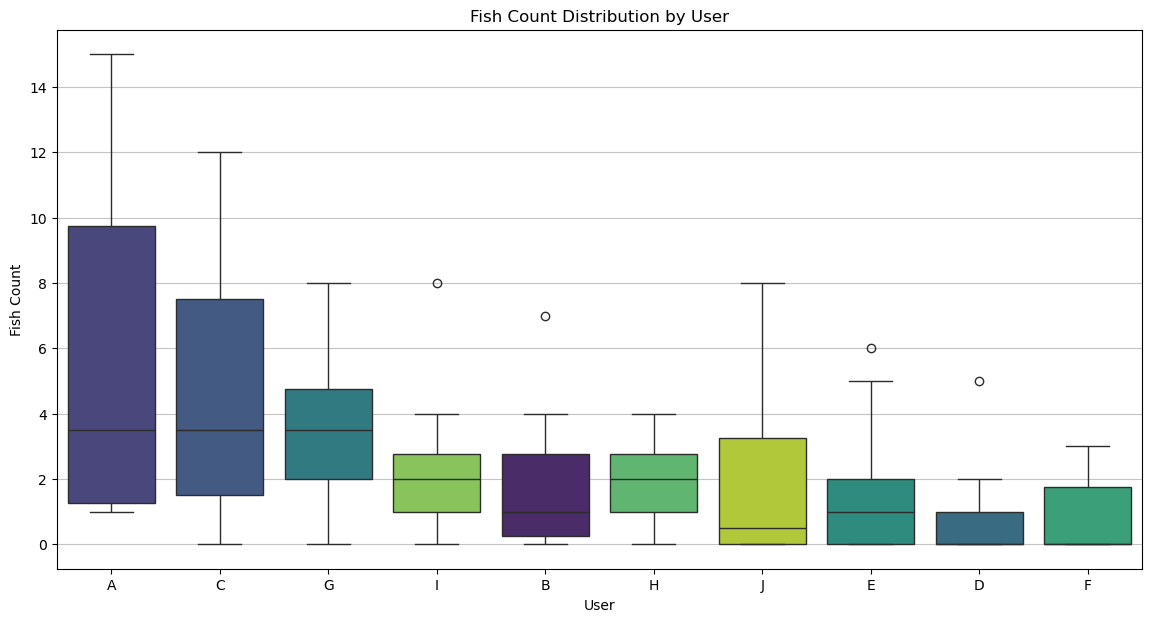

In [29]:
# 各ユーザーの釣果を箱ひげ図で可視化
user_fish_stats = df.groupby('user')['fish_count'].agg(['mean']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(14, 7))
sns.boxplot(x='user', y='fish_count', data=df, hue='user',order=user_fish_stats['mean'].sort_values(ascending=False).index, palette='viridis', legend=False)
plt.title('Fish Count Distribution by User')
plt.xlabel('User')
plt.ylabel('Fish Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [14]:
df.groupby('user')['fish_count'].describe()

,count,mean,std,min,25%,50%,75%,max
user,,,,,,,,
A,10.0,5.5,5.126185,1.0,1.25,3.5,9.75,15.0
B,10.0,1.9,2.233582,0.0,0.25,1.0,2.75,7.0
C,10.0,4.6,3.835507,0.0,1.50,3.5,7.50,12.0
D,10.0,0.9,1.595131,0.0,0.00,0.0,1.00,5.0
E,10.0,1.7,2.162817,0.0,0.00,1.0,2.00,6.0
F,10.0,0.8,1.135292,0.0,0.00,0.0,1.75,3.0
G,10.0,3.3,2.451757,0.0,2.00,3.5,4.75,8.0
H,10.0,1.9,1.197219,0.0,1.00,2.0,2.75,4.0
I,10.0,2.3,2.359378,0.0,1.00,2.0,2.75,8.0


平均釣果は外れ値による影響が大きいと考え、各ユーザーの釣果の分布をより詳細に把握するために、箱ひげ図を作成し、具体的な数値を見るために、ユーザーごとの釣果のデータ数、釣果の平均値、標準偏差、最小値、25%点、中央値、75%点、最大値の表を示した。釣果の平均値はユーザーAが群を抜いて高かったが、中央値はユーザーA、C、Gが同率であった。2つの図から、ユーザーA, C, Gは一貫して高いパフォーマンスを示し、ユーザーD, Fは釣果が安定して低い結果であった。

### 2.5 ユーザーと気温の関係

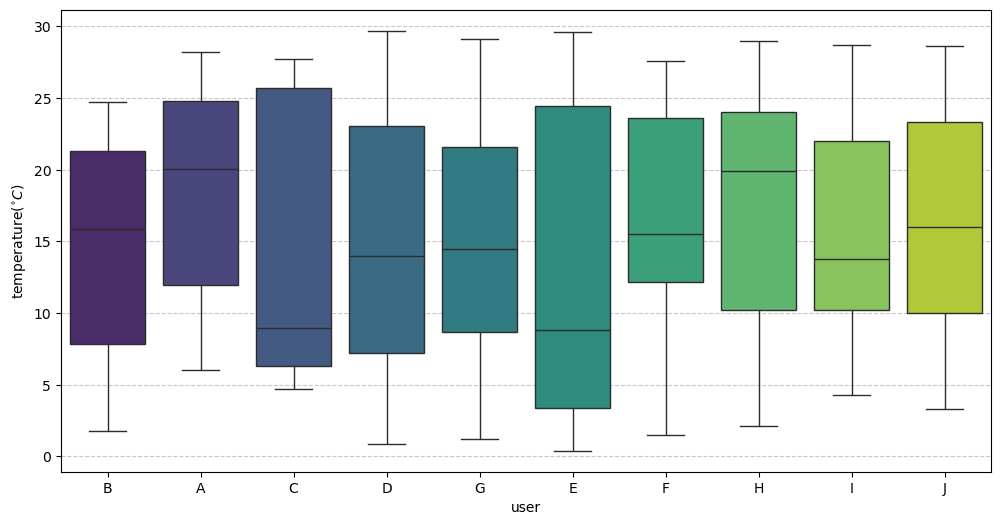

In [28]:
#各ユーザーの気温分布を箱ひげ図で可視化
plt.figure(figsize=(12, 6))
sns.boxplot(x='user', y='temperature', data=df, hue='user', palette='viridis', legend=False)
plt.xlabel('user')
plt.ylabel('temperature($^{\circ}C$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

2.2 釣果と気温の関係から、気温と釣果数には正の相関関係があることが分かった。この箱ひげ図は、各ユーザーが、どのくらいの気温の範囲で釣りを行っていたかを可視化したものである。まず、ユーザーごとに釣りをしていた気温の分布が異なっていることが読み取れる。例えば、ユーザーAは比較的暖かい日に釣りをしている傾向があり、ユーザーEは寒い日も含めて幅広い気温で釣りをしていて、ユーザーCは50%以上が10度以下での低い気温で釣りをしている、といった違いが見られる。ユーザーAは釣果の平均値も中央値も高かったが、気温が高いときに釣りをする回数が多いことで釣果数が多くなっている可能性が示唆される。

## 3. 簡易な予測モデルの構築

将来的に予測システムを作る前段階として、釣りがうまい人が晴れ・25度のときに何匹釣れるか予想する。ここで、ユーザー10人には初心者、中級者、上級者がいると仮定し、「釣りがうまい人」を上級者と定義する。

釣れる魚の数はポアソン分布に従うと仮定されるという前提より、Statsmodelのポアソン回帰モデルを適用する。

### 3.1 必要なライブラリのインポート

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

### 3.2 データの前処理

In [19]:
#訓練データとテストデータに分割
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['user'])

In [20]:
#カテゴリカル変数である天気とユーザーをダミー変数に変換
train_df_preprocessed = pd.get_dummies(train_df, columns=['weather', 'user'], drop_first=True, dtype=int)
train_df_preprocessed.head()

,fish_count,temperature,weather_sunny,user_B,user_C,user_D,user_E,user_F,user_G,user_H,user_I,user_J
20,11,26.7,0,0,0,0,0,0,0,0,0,0
10,1,8.2,0,0,0,0,0,0,0,0,0,0
17,3,26.6,0,0,0,0,0,0,0,1,0,0
22,3,6.3,0,0,1,0,0,0,0,0,0,0
85,0,1.5,1,0,0,0,0,1,0,0,0,0


### 3.3 ポアソン回帰モデルの構築

In [21]:
#訓練データでStatsmodelのポアソン回帰モデルを構築
model = smf.glm("fish_count ~ temperature + weather_sunny + user_B + user_C + user_D + user_E + user_F + user_G + user_H + user_I + user_J", data=train_df_preprocessed, family=sm.families.Poisson()).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:             fish_count   No. Observations:                   70
Model:                            GLM   Df Residuals:                       58
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -102.32
Date:                Fri, 11 Jul 2025   Deviance:                       60.524
Time:                        23:16:10   Pearson chi2:                     52.4
No. Iterations:                     6   Pseudo R-squ. (CS):             0.8939
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.1500      0.314     -0.478      0.633      -0.765       0.465
temperature       0.0929      0.011      8.497      0.000       0.071       0.114
weather_sunny    -0.4140      0.160     -2.586      0.010      -0.728      -0.100
user_B           -0.4900      0.315     -1.554      0.120      -1.108       0.128
user_C            0.0858      0.246      0.348      0.728      -0.397       0.569
user_D           -1.7967      0.530     -3.390      0.001      -2.836      -0.758
user_E           -0.8789      0.320     -2.750      0.006      -1.505      -0.253
user_F           -2.0525      0.604     -3.396      0.001      -3.237      -0.868
user_G           -0.1555      0.277     -0.561      0.575      -0.699       0.388
user_H           -0.9248      0.307     -3.009      0.003      -1.527      -0.322
user_I           -0.5482      0.286     -1.920      0.055      -1.108       0.011
user_J           -0.7267      0.323     -2.250      0.024      -1.360      -0.094
=================================================================================
"""

### 3.3 各ユーザーの係数に基づいてKMeans法でユーザーをスキルグループで分類

釣りがうまい人を、平均釣果が多い人をと定義すると、その人がたまたま魚が釣れやすい暖かい日ばかり釣りに行っていた可能性を排除できないため、ポアソン回帰モデルから得られたユーザーごとの係数を使ってクラスタリングした。つまり、この係数は天候や気温といったコンディションの差を補正した上での、より「純粋な釣りのうまさ」を数値化した指標と捉えることができる。また、スキルグループでモデルを単純化することで、モデルの汎化性能が高めることができる。

In [22]:
#ユーザーごとの係数を抽出
user_coeffs = model.params.filter(like='user').to_dict()
user_coeffs['user_A'] = 0.0  #ユーザーAの係数を追加

df_coeffs = pd.DataFrame(list(user_coeffs.items()), columns=['user_id', 'coefficient'])
df_coeffs['user_id'] = df_coeffs['user_id'].str.replace('user_', '')

#KMeansで3クラスタに分類
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_coeffs['cluster'] = kmeans.fit_predict(df_coeffs[['coefficient']])

#クラスターをbegginer, intermediate, advancedにマッピング
cluster_centers = kmeans.cluster_centers_
sorted_centers_indices = np.argsort(cluster_centers.flatten())
skill_map = {sorted_centers_indices[0]: 'begginer', sorted_centers_indices[1]: 'intermediate', sorted_centers_indices[2]: 'advanced'}
df_coeffs['skill_group'] = df_coeffs['cluster'].map(skill_map)

df_coeffs

C:\Users\tmkta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,user_id,coefficient,cluster,skill_group
0,B,-0.490002,0,intermediate
1,C,0.085826,1,advanced
2,D,-1.796684,2,begginer
3,E,-0.878931,0,intermediate
4,F,-2.052468,2,begginer
5,G,-0.155547,1,advanced
6,H,-0.924845,0,intermediate
7,I,-0.548156,0,intermediate
8,J,-0.726697,0,intermediate
9,A,0.000000,1,advanced


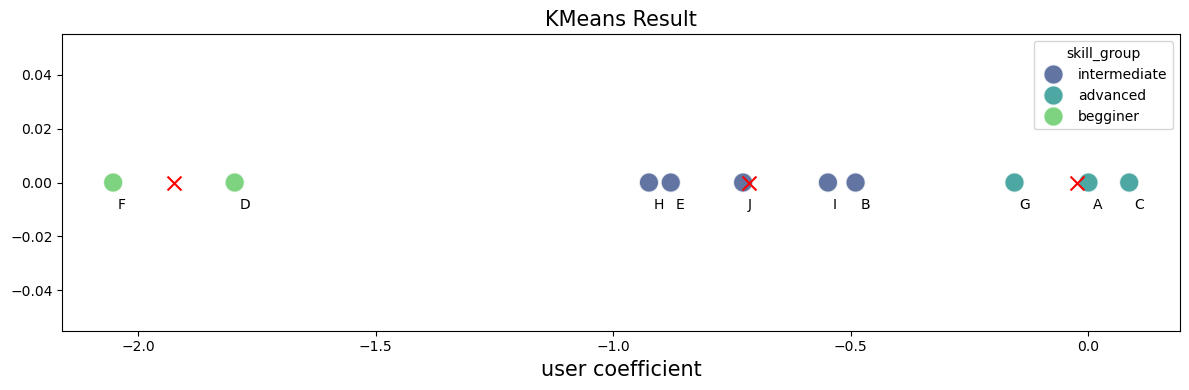

In [23]:
plt.figure(figsize=(12, 4))

#スキルグループごとに色分けした散布図を作成
sns.scatterplot(
    x='coefficient',
    y=np.zeros(len(df_coeffs)),
    hue='skill_group',
    data=df_coeffs,
    s=200,
    palette='viridis',
    alpha=0.8
)

#各クラスターのセントロイドをプロット
plt.scatter(
    x=cluster_centers.flatten(),
    y=np.zeros(len(cluster_centers)),
    marker='x',
    color='red',
    s=100,
    label='centroids',
)

#各データポイントにユーザーIDを追加
for i, row in df_coeffs.iterrows():
    plt.text(
        x=row['coefficient']+0.01,
        y=-0.01,
        s=row['user_id']
    )

plt.title('KMeans Result', fontsize=15)
plt.xlabel('user coefficient', fontsize=15)
plt.tight_layout()
plt.show()

### 3.4 初心者（begginer）・中級者（intermediate）・上級者（advanced）を特徴量にしてモデルを再構築

In [24]:
#訓練データとテストデータにスキルグループ情報を結合
train_with_skill = pd.merge(train_df, df_coeffs[['user_id', 'skill_group']], left_on='user', right_on='user_id').drop(columns=['user_id', 'user'])
test_with_skill = pd.merge(test_df, df_coeffs[['user_id', 'skill_group']], left_on='user', right_on='user_id').drop(columns=['user_id', 'user'])

#スキルグループを特徴量とした最終的なモデルを構築
final_model = smf.glm("fish_count ~ temperature + weather + skill_group", data=train_with_skill, family=sm.families.Poisson()).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:             fish_count   No. Observations:                   70
Model:                            GLM   Df Residuals:                       65
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -103.96
Date:                Fri, 11 Jul 2025   Deviance:                       63.807
Time:                        23:16:16   Pearson chi2:                     57.1
No. Iterations:                     6   Pseudo R-squ. (CS):             0.8888
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.1587      0.261     -0.608      0.543      -0.670       0.353
weather[T.sunny]               -0.3740      0.155     -2.417      0.016      -0.677      -0.071
skill_group[T.begginer]        -1.9098      0.394     -4.849      0.000      -2.682      -1.138
skill_group[T.intermediate]    -0.7028      0.156     -4.514      0.000      -1.008      -0.398
temperature                     0.0918      0.011      8.692      0.000       0.071       0.113
===============================================================================================
"""

疑似決定係数（Pseudo R-squ.）が0.8888と非常に高い値を示しており、これは、モデルに含まれる説明変数（天気、スキル、気温）が、釣果の変動の大部分を説明できていることを示唆している。スキルが最も影響の大きい要因であり、基準となっている上級者（advanced）と比較して、中級者（intermediate）の係数は-1.9098、初心者（begginer）の係数は-0.7028となっている。この係数は対数であるから、上級者に比べて初心者の釣果の期待値は約0.15倍、中級者の釣果の期待値は約0.50倍になる。気温は、1℃上昇するごとに、釣果の期待値が約1.10倍になり、気温が高いほど魚が釣れやすくなる傾向があるといえる。天気は、基準となる曇り（cloudy）と比較して、晴れ（sunny）の日は釣果の期待値が約0.69倍になり、晴れより曇りのほうが魚が釣れやすい傾向があるといえる。

### 3.5 釣果の予測

In [25]:
#上級者・晴れ・25℃のデータを作成
predict_data = pd.DataFrame({'skill_group': ['advanced'], 'weather': ['sunny'], 'temperature': [25]})

#最終モデルを使って予測を実行
predicted_count = final_model.predict(predict_data)

print(f"上級者が晴れ・25℃のときに予測される魚の数: {predicted_count.iloc[0]:.2f}匹")

上級者が晴れ・25℃のときに予測される魚の数: 5.83匹


### 3.6 モデルの性能評価

In [26]:
#訓練データとテストデータの予測値
train_predictions = final_model.predict(train_with_skill) 
test_predictions = final_model.predict(test_with_skill) 

#平均二乗誤差 (MSE) の計算
mse_train = ((train_with_skill['fish_count'] - train_predictions) ** 2).mean()
mse_test = ((test_with_skill['fish_count'] - test_predictions) ** 2).mean()
print(f"訓練データに対するMSE: {mse_train:.2f}, テストデータに対するMSE: {mse_test:.2f}")

#対数尤度の計算
log_likelihood = final_model.llf
print(f"最終モデルの対数尤度: {log_likelihood:.2f}")

訓練データに対するMSE: 2.03, テストデータに対するMSE: 2.99
最終モデルの対数尤度: -103.96


以上のモデルでは、ポアソン回帰の係数を用いてユーザーを上級者・中級者・初心者の3つのスキルグループに分類し、釣りがうまい人が晴れ・25℃のときに予測される魚の数は5.83匹だと予測できた。  
訓練データに対する平均二乗誤差（MSE）は2.03、未知のテストデータに対するMSEは2.99となった。